In [2]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# load models
unet_model = tf.keras.models.load_model('models/best_model.keras')
yolo_model = YOLO("models/best_model.pt")

In [4]:
# color scheme
COLORS = {
    'free': (0, 255, 0),    # Green
    'occupied': (0, 0, 255), # Red
    'text': (255, 255, 255)  # White
}

In [5]:
def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two rectangles"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    
    return intersection / (area1 + area2 - intersection + 1e-6)

In [6]:
def merge_contours(contours, max_distance=75):
    """Merge nearby contours with improved logic"""
    merged = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        found = False
        for idx, (mx, my, mw, mh) in enumerate(merged):
            if (abs(x - mx) < max_distance and 
                abs(y - my) < max_distance and 
                abs(x+w - mx-mw) < max_distance):
                # Merge rectangles
                new_x = min(x, mx)
                new_y = min(y, my)
                new_w = max(x+w, mx+mw) - new_x
                new_h = max(y+h, my+mh) - new_y
                merged[idx] = (new_x, new_y, new_w, new_h)
                found = True
                break
        if not found:
            merged.append((x, y, w, h))
    return merged

In [7]:
def analyze_parking_space(image_path):
    # load and process image
    original_img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w = original_img.shape[:2]
    
    # unet processing with enhanced morphology
    unet_input = cv2.resize(original_img, (256, 256)) / 255.0
    mask = unet_model.predict(np.expand_dims(unet_input, axis=0))[0]
    parking_mask = (mask.squeeze() > 0.5).astype(np.uint8)
    parking_mask = cv2.resize(parking_mask, (w, h))
    
    # morphological operations
    kernel = np.ones((25,25), np.uint8)
    parking_mask = cv2.morphologyEx(parking_mask, cv2.MORPH_CLOSE, kernel)
    parking_mask = cv2.morphologyEx(parking_mask, cv2.MORPH_OPEN, np.ones((7,7), np.uint8))
    
    # contour processing
    contours, _ = cv2.findContours(parking_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [c for c in contours if cv2.contourArea(c) > 1500]
    merged_rects = merge_contours(filtered)
    
    # yolo detection
    results = yolo_model.predict(original_img, conf=0.4)
    car_boxes = results[0].boxes.xyxy.cpu().numpy()
    
    # parking space analysis
    overlay = original_img.copy()
    occupied = 0
    
    for rect in merged_rects:
        x, y, w, h = rect
        space_box = [x, y, x+w, y+h]
        is_occupied = False
        
        for car in car_boxes:
            car_box = [int(c) for c in car]
            iou = calculate_iou(space_box, car_box)
            if iou > 0.1:  # IoU threshold
                is_occupied = True
                break
        
        color = COLORS['occupied'] if is_occupied else COLORS['free']
        cv2.rectangle(overlay, (x, y), (x+w, y+h), color, 2)
        occupied += int(is_occupied)
    
    # Add info text
    total = len(merged_rects)
    text = f"Occupied: {occupied} | Free: {total - occupied}"
    cv2.putText(overlay, text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 
               1, COLORS['text'], 2, cv2.LINE_AA)
    
    return original_img, overlay, occupied

In [8]:
def plot_results(original, overlay):
    plt.figure(figsize=(15, 8))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title('Parking Space Analysis')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step

0: 640x640 1 cars-sUYr, 96.9ms
Speed: 4.1ms preprocess, 96.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


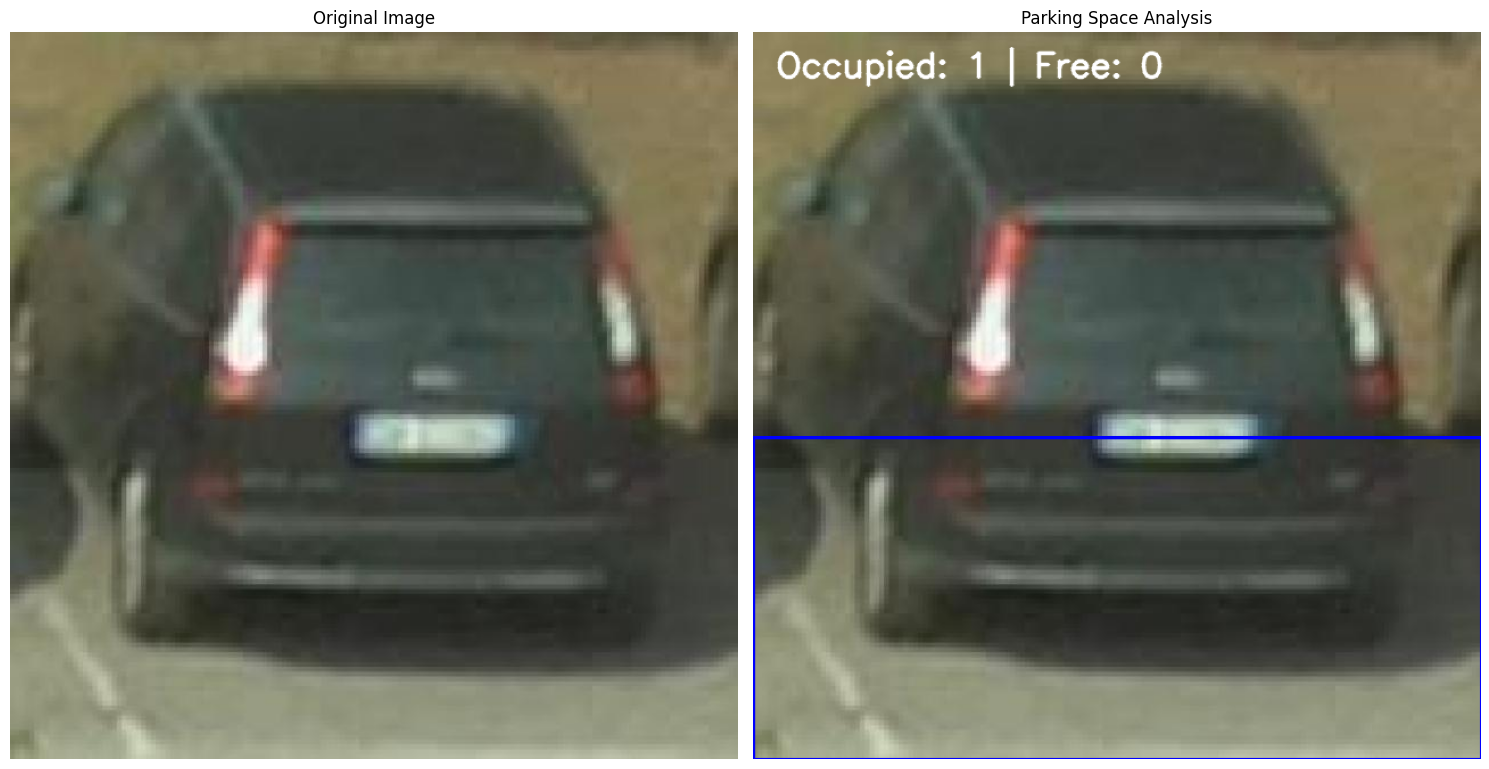

In [9]:
# test with an image
test_image_path = 'dataset/test_data/images/(3).jpg'
original, result, count = analyze_parking_space(test_image_path)
plot_results(original, result)